In [84]:
folder_path = "../results/"

In [85]:
import os
import pandas as pd
df = pd.DataFrame(columns=[
    "model",
    "cwe",
    "iqr",
    "mean",
    "median",
    "min",
    "max",
    "perplexity"
])
for file in os.listdir(folder_path):
    if file.endswith(".jsonl") and file not in ["NVD-CWE-Other.jsonl"]:
        with open(folder_path + "/" + file, "r") as f:
            lines = f.readlines()
            import json
            for line in lines:
                data = json.loads(line)
                # {"cwe": "CWE-16", "model": "openai-community/gpt2", "vulnerable": [1717.9267578125], "safe": [372.79498291015625]}
                model = data["model"]
                cwe = data["cwe"]
                vulnerable = data["vulnerable"]
                safe = data["safe"]
                # compute the IQR
                import numpy as np
                vulnerable = np.array(vulnerable)
                safe = np.array(safe)
                iqr_vulnerable = np.percentile(vulnerable, 75) - np.percentile(vulnerable, 25)
                iqr_safe = np.percentile(safe, 75) - np.percentile(safe, 25)

                # compute the mean
                mean_vulnerable = np.mean(vulnerable)
                mean_safe = np.mean(safe)

                # compute the median
                median_vulnerable = np.median(vulnerable)
                median_safe = np.median(safe)

                # compute the min
                min_vulnerable = np.min(vulnerable)
                min_safe = np.min(safe)

                # compute the max
                max_vulnerable = np.max(vulnerable)
                max_safe = np.max(safe)

                # Store the results in a dataframe
                results_vulnerable = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe],
                    "iqr": [iqr_vulnerable],
                    "mean": [mean_vulnerable],
                    "median": [median_vulnerable],
                    "min": [min_vulnerable],
                    "max": [max_vulnerable],
                    "perplexity": [vulnerable]
                })
                results_safe = pd.DataFrame({
                    "model": [model],
                    "cwe": [cwe+" Patched"],
                    "iqr": [iqr_safe],
                    "mean": [mean_safe],
                    "median": [median_safe],
                    "min": [min_safe],
                    "max": [max_safe],
                    "perplexity": [safe]
                })
                
                df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)
                

    
                

/var/folders/b4/lwfgccm95kqd2skcwvrt2fr00000gn/T/ipykernel_82541/761664232.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, results_vulnerable, results_safe], ignore_index=True)


In [86]:
df["CWE_Number"] = df["cwe"].str.extract(r'(\d+)').astype(int)
df = df.sort_values(by=["CWE_Number", "model"])
#df = df.drop(columns=["CWE_Number"])
df

,model,cwe,iqr,mean,median,min,max,perplexity,CWE_Number
82,openai-community/gpt2,CWE-16,0.000000,1717.926758,1717.926758,1717.926758,1717.926758,[1717.9267578125],16
83,openai-community/gpt2,CWE-16 Patched,0.000000,372.794983,372.794983,372.794983,372.794983,[372.79498291015625],16
36,meta-llama/Llama-3.2-3B-Instruct,CWE-17,0.883624,5.415808,4.498978,2.693867,17.656168,"[4.3173723220825195, 3.98305344581604, 2.69386...",17
37,meta-llama/Llama-3.2-3B-Instruct,CWE-17 Patched,0.934348,5.498369,4.469694,2.652120,18.803772,"[4.362307071685791, 3.7850418090820312, 2.6521...",17
34,openai-community/gpt2,CWE-17,504.357198,533.361542,210.662758,5.140015,2905.974365,"[11.427721977233887, 7.940468788146973, 5.1400...",17
...,...,...,...,...,...,...,...,...,...
199,openai-community/gpt2,CWE-924 Patched,0.000000,8.924274,8.924274,8.924274,8.924274,[8.924274444580078],924
6,meta-llama/Llama-3.2-3B-Instruct,CWE-1021,0.000000,8.198041,8.198041,8.198041,8.198041,[8.198040962219238],1021
7,meta-llama/Llama-3.2-3B-Instruct,CWE-1021 Patched,0.000000,8.104796,8.104796,8.104796,8.104796,[8.104796409606934],1021
4,openai-community/gpt2,CWE-1021,0.000000,12.000200,12.000200,12.000200,12.000200,[12.000200271606445],1021


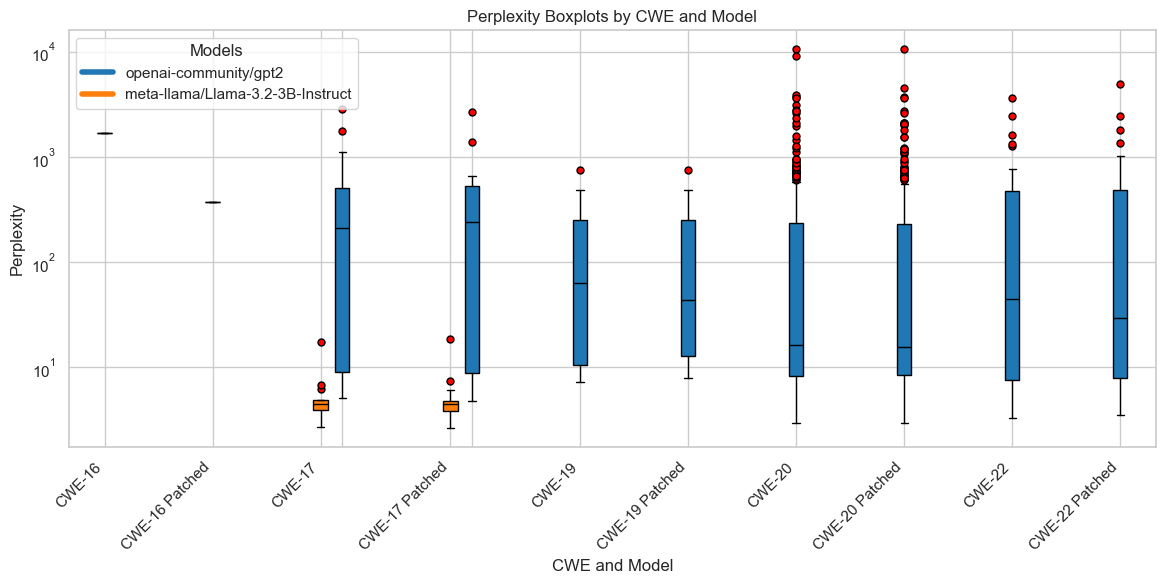

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# # Sample DataFrame
# np.random.seed(42)
# data = {
#     "cwe": np.random.choice(["CWE-1", "CWE-2", "CWE-3", "CWE-4"], size=100),
#     "model": np.random.choice(["Model-A", "Model-B", "Model-C"], size=100),
#     "perplexity": np.random.rand(100) * 100
# }
# df = pd.DataFrame(data)


def plot_grouped_boxplots(df, cwe_subset, model_colors):
    plt.figure(figsize=(12, 6))
    
    # Filter data for selected CWEs
    subset_df = df[df["cwe"].isin(cwe_subset)]
    
    # Sort dataframe by CWE and model
    sorted_df = subset_df.sort_values(by=['cwe', 'model'])
    
    positions = []
    labels = []
    idx = 0
    cwe_spacing = 1.5  # Control spacing between different CWEs
    model_spacing = 0.3  # Control spacing between models under the same CWE

    legend_handles = {}  # To store legend handles
    
    # Grouping by CWE
    for cwe in sorted_df["cwe"].unique():
        cwe_df = sorted_df[sorted_df["cwe"] == cwe]
        cwe_base_idx = idx
        
        for j, model in enumerate(cwe_df["model"].unique()):
            model_df = cwe_df[cwe_df["model"] == model]
            pos = cwe_base_idx + j * model_spacing
            
            # Create boxplot and capture its elements
            box = plt.boxplot(
                model_df["perplexity"],
                positions=[pos],
                widths=0.2,
                patch_artist=True,
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker="o", markersize=5, markerfacecolor="red"),
            )
            
            # Color the boxes appropriately
            for b in box['boxes']:
                b.set_facecolor(model_colors[model])

            # Store legend info
            if model not in legend_handles:
                legend_handles[model] = plt.Line2D([0], [0], color=model_colors[model], lw=4, label=model)

            if cwe not in labels:
                labels.append(cwe)
            else:
                labels.append("")
            positions.append(pos)
            
        # Update the index to keep CWEs close together
        idx = pos + cwe_spacing
    
    # Adjust x-axis labels
    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.xlabel("CWE and Model")
    plt.ylabel("Perplexity")
    plt.title("Perplexity Boxplots by CWE and Model")
    plt.legend(handles=legend_handles.values(), title="Models")  # Add legend
    plt.tight_layout()
    plt.yscale("log")
    plt.show()

# Get unique CWE values
unique_cwes = df["cwe"].unique()

# Assign colors to models
unique_models = df['model'].unique()
model_colors = {model: plt.cm.tab10(i % 10) for i, model in enumerate(unique_models)}

# Define batch size
batch_size = 10

# Generate plots in batches
for i in range(0, len(unique_cwes), batch_size):
    cwe_batch = unique_cwes[i:i+batch_size]
    plot_grouped_boxplots(df, cwe_batch, model_colors)
    break